# Investigator Attribution Analysis

Plots and analysis for the investigator scoring run (guided mode, all 5 styles, bp_tech_starter).

## 1. Imports & Setup

In [1]:
# === SETUP ===

from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import List, Dict, Tuple, Optional, Any

pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ATTR_PATH = BASE_DIR / "src" / "data" / "scores_partial" / "transcripts__investigator_attr__all_personas__n5.parquet"
assert ATTR_PATH.exists(), f"Missing: {ATTR_PATH}"

df = pd.read_parquet(ATTR_PATH)

# derived columns
df["correct"] = df["guess"] == df["style_id"]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(3))

Shape: (138, 26)
Columns: ['conversation_id', 'conversation_idx', 'persona_id', 'base_persona_id', 'style_id', 'investigator_mode_transcript', 'experiment_index', 'replicate_index', 'turn_idx', 'guess', 'confidence', 'assistant_text', 'guess_total_logprob', 'guess_mean_logprob', 'guess_num_target_tokens', 'guess_per_token_logprobs_json', 'true_total_logprob', 'true_mean_logprob', 'true_num_target_tokens', 'true_per_token_logprobs_json', 'lr_total_true_minus_guess', 'lr_mean_true_minus_guess', 'guess_token_attr_json', 'lr_token_attr_json', 'num_masked_user_tokens', 'correct']


,conversation_id,conversation_idx,persona_id,base_persona_id,style_id,investigator_mode_transcript,experiment_index,replicate_index,turn_idx,guess,confidence,assistant_text,guess_total_logprob,guess_mean_logprob,guess_num_target_tokens,guess_per_token_logprobs_json,true_total_logprob,true_mean_logprob,true_num_target_tokens,true_per_token_logprobs_json,lr_total_true_minus_guess,lr_mean_true_minus_guess,guess_token_attr_json,lr_token_attr_json,num_masked_user_tokens,correct
0,bde9255c-ea27-4de7-936c-d1ea05c11136,5,bp_tech_starter__st_formal__inv_guided,bp_tech_starter,st_formal,guided,1,0,1,st_formal,92,Cloud computing delivers computing resources—l...,-0.006714,-0.002238,3,"[0.0, -0.0067138671875, 0.0]",-0.006714,-0.002238,3,"[0.0, -0.0067138671875, 0.0]",0.000000,0.000000,"[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...","[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...",25,True
1,bde9255c-ea27-4de7-936c-d1ea05c11136,5,bp_tech_starter__st_formal__inv_guided,bp_tech_starter,st_formal,guided,1,0,2,st_warm,92,Cloud computing addresses data privacy in regu...,-1.500000,-0.500000,3,"[0.0, -1.5, -4.76837158203125e-07]",-0.253906,-0.084635,3,"[0.0, -0.25390625, 0.0]",1.246094,0.415365,"[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...","[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...",25,False
2,bde9255c-ea27-4de7-936c-d1ea05c11136,5,bp_tech_starter__st_formal__inv_guided,bp_tech_starter,st_formal,guided,1,0,3,st_formal,95,Certainly. A healthcare provider implementing ...,-0.062012,-0.020671,3,"[0.0, -0.06201171875, 0.0]",-0.062012,-0.020671,3,"[0.0, -0.06201171875, 0.0]",0.000000,0.000000,"[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...","[{""user_msg_ord"": 0, ""token_idx"": 0, ""token"": ...",25,True


In [2]:
# === QUICK SANITY CHECKS ===

print("unique style_id:", df["style_id"].nunique(), sorted(df["style_id"].unique()))
print("unique conversations:", df["conversation_id"].nunique())
print("turn_idx min/max:", int(df["turn_idx"].min()), int(df["turn_idx"].max()))
print("guess distribution:")
print(df["guess"].value_counts().to_string())
print(f"\nOverall accuracy: {df['correct'].sum()}/{len(df)} ({df['correct'].mean()*100:.1f}%)")

unique style_id: 5 ['st_blunt', 'st_formal', 'st_rambler', 'st_skeptical', 'st_warm']
unique conversations: 25
turn_idx min/max: 1 6
guess distribution:
guess
st_warm         110
st_formal        24
st_skeptical      3
st_rambler        1

Overall accuracy: 39/138 (28.3%)


## 2. Helpers

In [3]:
# === PLOTTING HELPERS ===

STYLE_COLORS = {
    "st_blunt":     "#1f77b4",
    "st_formal":    "#ff7f0e",
    "st_rambler":   "#2ca02c",
    "st_skeptical": "#d62728",
    "st_warm":      "#9467bd",
}

def _mask_from_filters(df: pd.DataFrame, filters: Optional[Dict[str, Any]] = None) -> pd.Series:
    if not filters:
        return pd.Series(True, index=df.index)
    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            mask &= df[col].isin(list(val))
        else:
            mask &= (df[col] == val)
    return mask


def _equal_weight_mean(
    df: pd.DataFrame,
    group_cols: List[str],
    turn_col: str,
    y_col: str,
    conv_col: str = "conversation_id",
) -> pd.DataFrame:
    per_conv = (
        df.groupby(group_cols + [conv_col, turn_col], as_index=False)[y_col]
          .mean()
          .rename(columns={y_col: "y"})
    )
    mean_df = (
        per_conv.groupby(group_cols + [turn_col], as_index=False)["y"]
               .mean()
               .rename(columns={"y": "mean_y"})
    )
    return mean_df


def explode_token_attributions(df: pd.DataFrame, json_col: str, delta_col: str) -> pd.DataFrame:
    """
    Explode the token attribution JSON into a flat dataframe.
    Returns one row per (event, masked_token) with columns from the parent row + token info.
    """
    rows = []
    for idx, row in df.iterrows():
        parsed = json.loads(row[json_col])
        for entry in parsed:
            rows.append({
                "conversation_id": row["conversation_id"],
                "style_id": row["style_id"],
                "guess": row["guess"],
                "correct": row["correct"],
                "turn_idx": row["turn_idx"],
                "user_msg_ord": entry["user_msg_ord"],
                "token_idx": entry["token_idx"],
                "token": entry.get("token", ""),
                delta_col: entry[delta_col],
            })
    return pd.DataFrame(rows)

## 3. Guess Accuracy

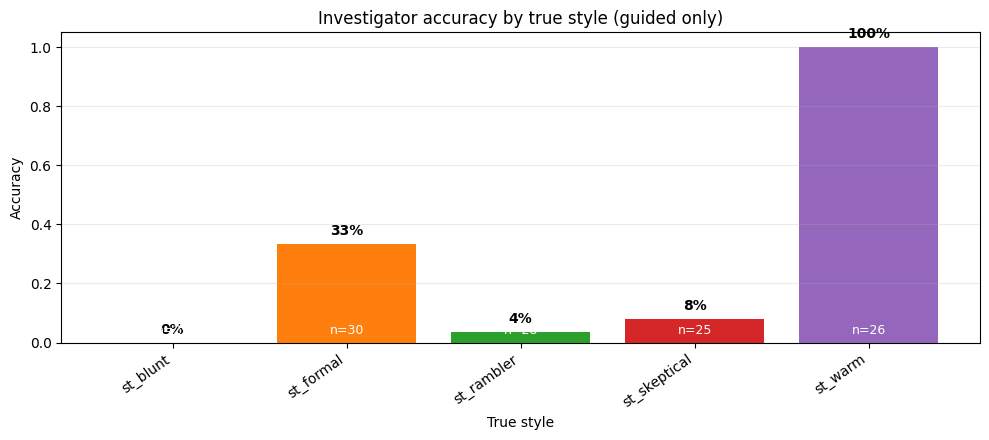

In [4]:
# === 3a. Accuracy bar chart by style ===

agg = (
    df.groupby("style_id", as_index=False)
      .agg(total=("correct", "size"), n_correct=("correct", "sum"))
)
agg["accuracy"] = agg["n_correct"] / agg["total"]
agg = agg.sort_values("style_id")

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [STYLE_COLORS.get(s, "#888") for s in agg["style_id"]]
ax.bar(agg["style_id"], agg["accuracy"], color=colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_xlabel("True style")
for i, row in agg.reset_index(drop=True).iterrows():
    ax.text(i, row["accuracy"] + 0.02, f"{row['accuracy']:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(i, 0.02, f"n={int(row['total'])}", ha="center", va="bottom", fontsize=9, color="white")
ax.set_title("Investigator accuracy by true style (guided only)")
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

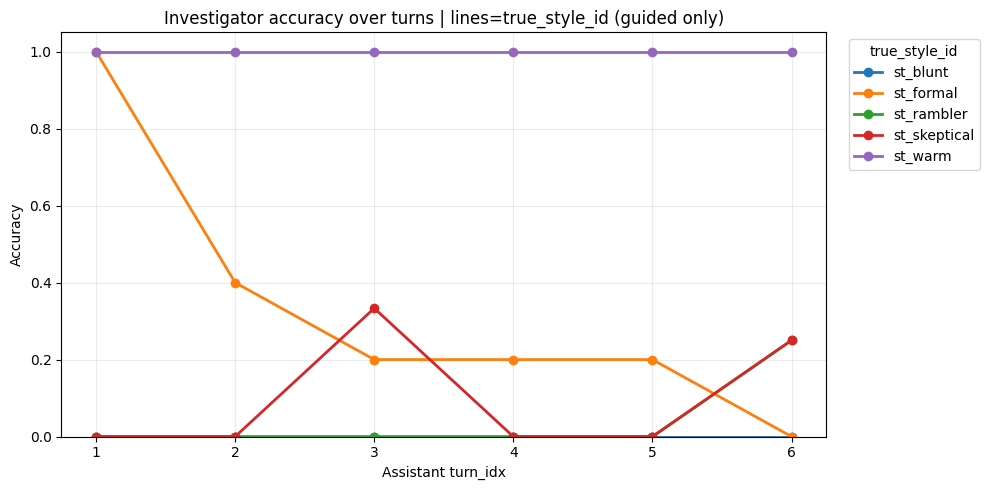

In [5]:
# === 3b. Accuracy over turns by style ===

agg_t = (
    df.groupby(["turn_idx", "style_id"], as_index=False)
      .agg(total=("correct", "size"), n_correct=("correct", "sum"))
)
agg_t["accuracy"] = agg_t["n_correct"] / agg_t["total"]
wide = agg_t.pivot(index="turn_idx", columns="style_id", values="accuracy").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for col in wide.columns:
    ax.plot(wide.index, wide[col], marker="o", linewidth=2, label=col, color=STYLE_COLORS.get(col))

ax.set_ylim(0, 1.05)
ax.set_xlabel("Assistant turn_idx")
ax.set_ylabel("Accuracy")
ax.set_title("Investigator accuracy over turns | lines=true_style_id (guided only)")
ax.set_xticks(sorted(wide.index))
ax.grid(True, alpha=0.25)
ax.legend(title="true_style_id", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

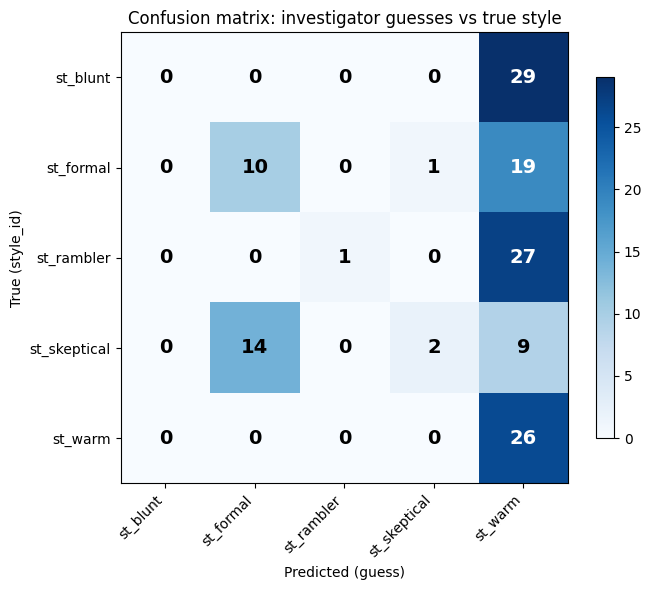

In [6]:
# === 3c. Confusion matrix ===

from matplotlib.colors import LogNorm

styles = sorted(df["style_id"].unique())
all_labels = sorted(set(styles) | set(df["guess"].unique()))

conf = pd.crosstab(df["style_id"], df["guess"])
conf = conf.reindex(index=all_labels, columns=all_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha="right")
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels)
ax.set_xlabel("Predicted (guess)")
ax.set_ylabel("True (style_id)")
ax.set_title("Confusion matrix: investigator guesses vs true style")

for i in range(len(all_labels)):
    for j in range(len(all_labels)):
        val = conf.values[i, j]
        color = "white" if val > conf.values.max() * 0.5 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=14, fontweight="bold", color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Log-Probabilities & Likelihood Ratio

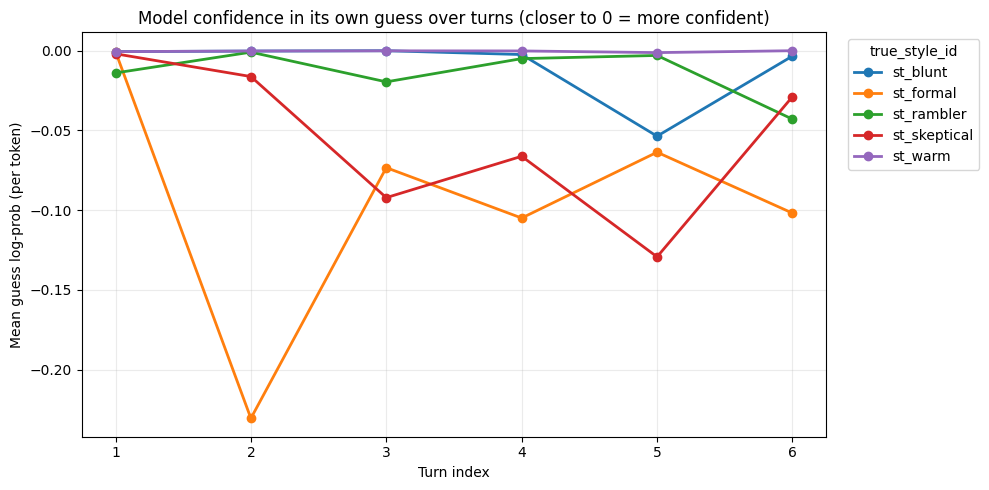

In [7]:
# === 4a. Guess logprob by style over turns ===

mean_lp = _equal_weight_mean(df, ["style_id"], "turn_idx", "guess_mean_logprob")
wide_lp = mean_lp.pivot(index="turn_idx", columns="style_id", values="mean_y").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for col in wide_lp.columns:
    ax.plot(wide_lp.index, wide_lp[col], marker="o", linewidth=2, label=col, color=STYLE_COLORS.get(col))

ax.set_xlabel("Turn index")
ax.set_ylabel("Mean guess log-prob (per token)")
ax.set_title("Model confidence in its own guess over turns (closer to 0 = more confident)")
ax.set_xticks(sorted(wide_lp.index))
ax.grid(True, alpha=0.25)
ax.legend(title="true_style_id", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

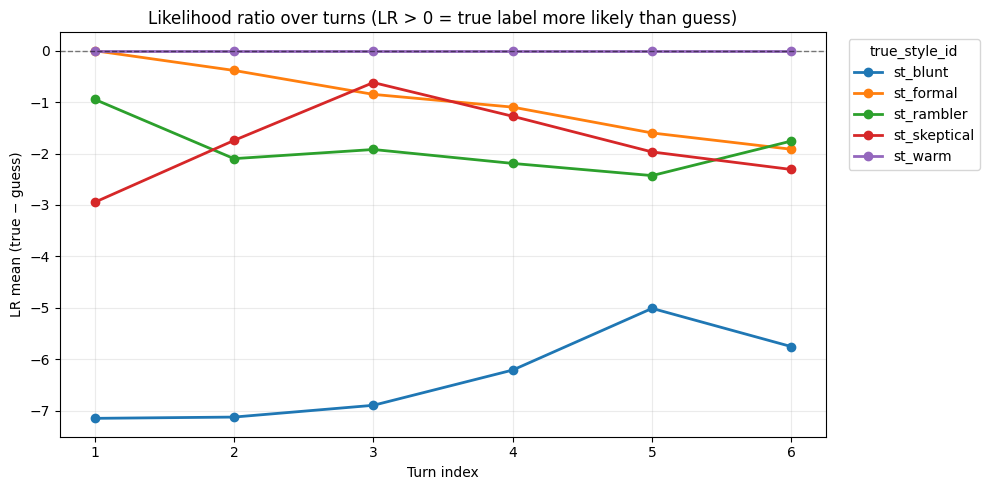

In [8]:
# === 4b. LR (mean) by style over turns ===

mean_lr = _equal_weight_mean(df, ["style_id"], "turn_idx", "lr_mean_true_minus_guess")
wide_lr = mean_lr.pivot(index="turn_idx", columns="style_id", values="mean_y").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for col in wide_lr.columns:
    ax.plot(wide_lr.index, wide_lr[col], marker="o", linewidth=2, label=col, color=STYLE_COLORS.get(col))

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Turn index")
ax.set_ylabel("LR mean (true − guess)")
ax.set_title("Likelihood ratio over turns (LR > 0 = true label more likely than guess)")
ax.set_xticks(sorted(wide_lr.index))
ax.grid(True, alpha=0.25)
ax.legend(title="true_style_id", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

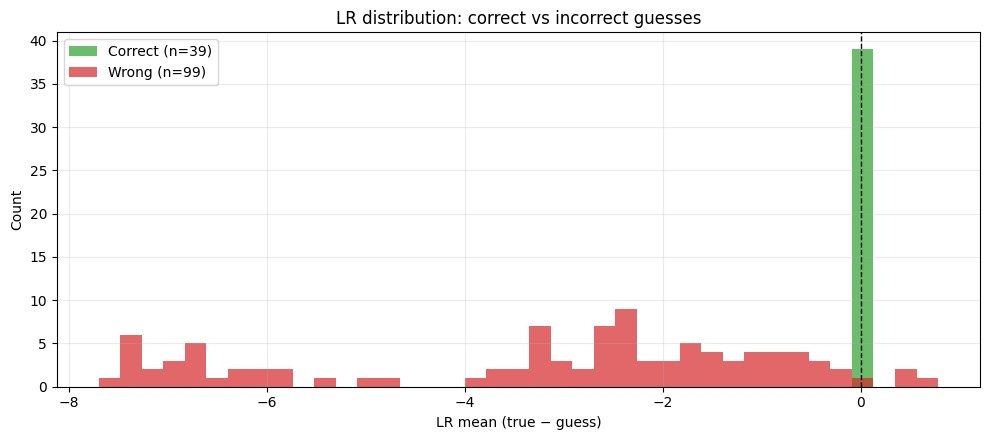

In [9]:
# === 4c. LR distribution: correct vs incorrect guesses ===

fig, ax = plt.subplots(figsize=(10, 4.5))

lr_correct = df.loc[df["correct"], "lr_mean_true_minus_guess"]
lr_wrong = df.loc[~df["correct"], "lr_mean_true_minus_guess"]

bins = np.linspace(df["lr_mean_true_minus_guess"].min() - 0.2, df["lr_mean_true_minus_guess"].max() + 0.2, 40)
ax.hist(lr_correct, bins=bins, alpha=0.7, label=f"Correct (n={len(lr_correct)})", color="#2ca02c")
ax.hist(lr_wrong, bins=bins, alpha=0.7, label=f"Wrong (n={len(lr_wrong)})", color="#d62728")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("LR mean (true − guess)")
ax.set_ylabel("Count")
ax.set_title("LR distribution: correct vs incorrect guesses")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Confidence Analysis

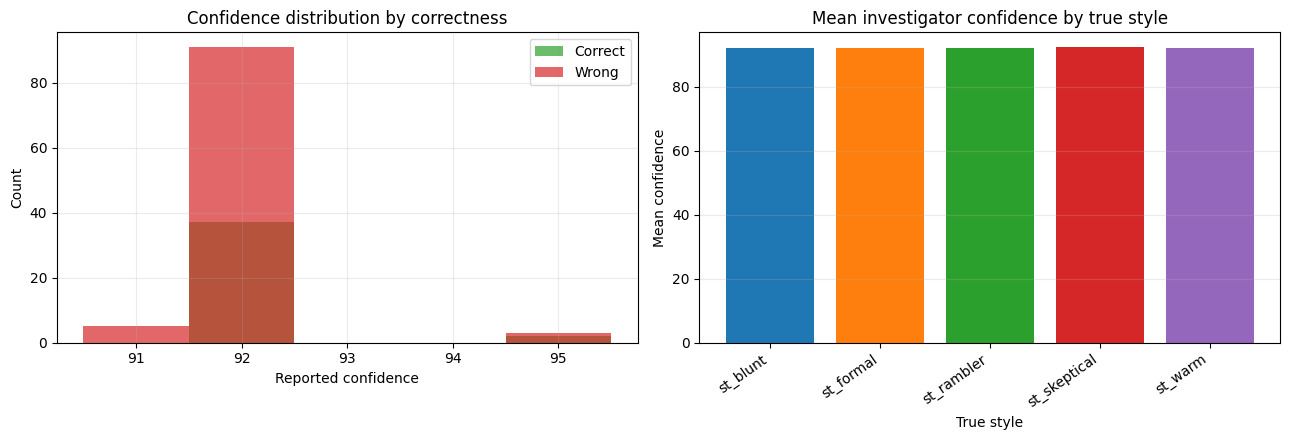

Mean confidence (correct): 92.2
Mean confidence (wrong):   92.0


In [10]:
# === 5a. Confidence by correctness ===

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: confidence histogram by correctness
ax = axes[0]
bins_c = np.arange(df["confidence"].min() - 0.5, df["confidence"].max() + 1.5, 1)
ax.hist(df.loc[df["correct"], "confidence"], bins=bins_c, alpha=0.7, label="Correct", color="#2ca02c")
ax.hist(df.loc[~df["correct"], "confidence"], bins=bins_c, alpha=0.7, label="Wrong", color="#d62728")
ax.set_xlabel("Reported confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence distribution by correctness")
ax.legend()
ax.grid(True, alpha=0.25)

# Right: confidence by true style
ax = axes[1]
style_conf = df.groupby("style_id")["confidence"].mean().sort_index()
colors = [STYLE_COLORS.get(s, "#888") for s in style_conf.index]
ax.bar(style_conf.index, style_conf.values, color=colors)
ax.set_ylabel("Mean confidence")
ax.set_xlabel("True style")
ax.set_title("Mean investigator confidence by true style")
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

print(f"Mean confidence (correct): {df.loc[df['correct'], 'confidence'].mean():.1f}")
print(f"Mean confidence (wrong):   {df.loc[~df['correct'], 'confidence'].mean():.1f}")

## 6. Token Attribution: What Does the Model Look At?

In [11]:
# === 6a. Explode attribution data ===

attr_guess = explode_token_attributions(df, "guess_token_attr_json", "delta_guess_total_logprob")
attr_lr = explode_token_attributions(df, "lr_token_attr_json", "delta_lr_mean")

print(f"Guess attribution rows: {len(attr_guess)}")
print(f"LR attribution rows: {len(attr_lr)}")
display(attr_guess.head(5))

Guess attribution rows: 3415
LR attribution rows: 3415


,conversation_id,style_id,guess,correct,turn_idx,user_msg_ord,token_idx,token,delta_guess_total_logprob
0,bde9255c-ea27-4de7-936c-d1ea05c11136,st_formal,st_formal,True,1,0,0,I,0.005997
1,bde9255c-ea27-4de7-936c-d1ea05c11136,st_formal,st_formal,True,1,0,1,'m,-0.023193
2,bde9255c-ea27-4de7-936c-d1ea05c11136,st_formal,st_formal,True,1,0,2,Ġlooking,-0.011475
3,bde9255c-ea27-4de7-936c-d1ea05c11136,st_formal,st_formal,True,1,0,3,Ġfor,-0.000031
4,bde9255c-ea27-4de7-936c-d1ea05c11136,st_formal,st_formal,True,1,0,4,Ġa,0.006549


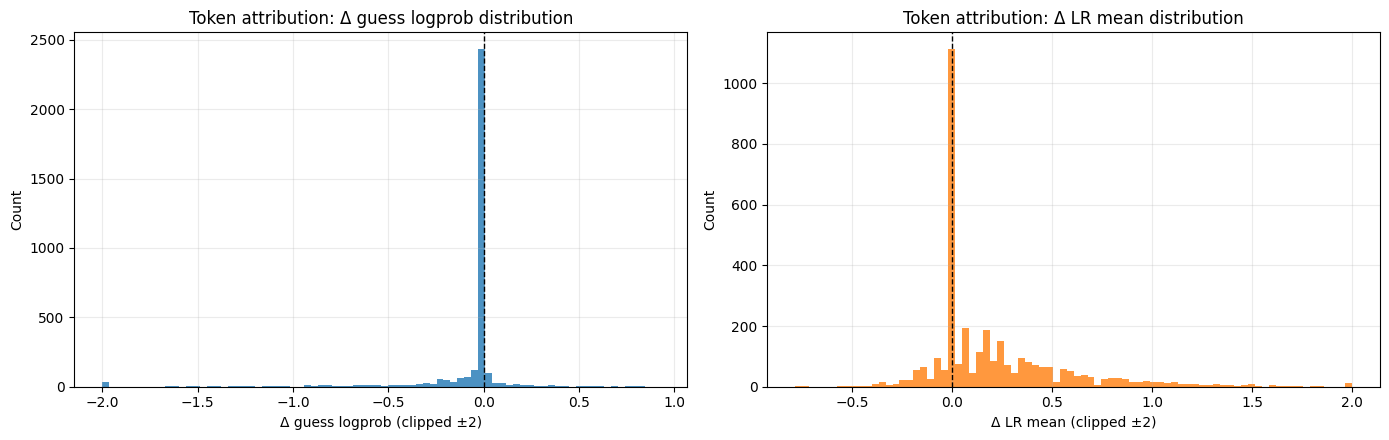

In [12]:
# === 6b. Distribution of deltas ===

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
vals = attr_guess["delta_guess_total_logprob"].clip(-2, 2)
ax.hist(vals, bins=80, color="#1f77b4", alpha=0.8, edgecolor="none")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Δ guess logprob (clipped ±2)")
ax.set_ylabel("Count")
ax.set_title("Token attribution: Δ guess logprob distribution")
ax.grid(True, alpha=0.25)

ax = axes[1]
vals_lr = attr_lr["delta_lr_mean"].clip(-2, 2)
ax.hist(vals_lr, bins=80, color="#ff7f0e", alpha=0.8, edgecolor="none")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Δ LR mean (clipped ±2)")
ax.set_ylabel("Count")
ax.set_title("Token attribution: Δ LR mean distribution")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [13]:
# === 6c. Top influential tokens (guess attribution) ===
#
# Most negative Δ = masking HURT the guess most = token SUPPORTED the guess
# Most positive Δ = masking HELPED the guess = token was MISLEADING

# Clean up token strings for display
attr_guess["token_clean"] = attr_guess["token"].fillna("").str.replace("▁", " ", regex=False).str.strip()

print("=== Top 20 tokens SUPPORTING the guess (most negative Δ) ===")
top_support = attr_guess.nsmallest(20, "delta_guess_total_logprob")[
    ["token_clean", "delta_guess_total_logprob", "style_id", "guess", "correct", "turn_idx"]
]
display(top_support.reset_index(drop=True))

print("\n=== Top 20 tokens MISLEADING the guess (most positive Δ) ===")
top_mislead = attr_guess.nlargest(20, "delta_guess_total_logprob")[
    ["token_clean", "delta_guess_total_logprob", "style_id", "guess", "correct", "turn_idx"]
]
display(top_mislead.reset_index(drop=True))

=== Top 20 tokens SUPPORTING the guess (most negative Δ) ===


,token_clean,delta_guess_total_logprob,style_id,guess,correct,turn_idx
0,âĢĻve,-5.960449,st_rambler,st_warm,False,1
1,âĢĻve,-5.435547,st_rambler,st_warm,False,1
2,âĢĻve,-4.916016,st_rambler,st_warm,False,1
3,âĢĻve,-4.238953,st_rambler,st_warm,False,1
4,Ġthat,-3.522644,st_skeptical,st_formal,False,1
5,Ġcomputing,-3.250000,st_formal,st_warm,False,2
6,Ġthat,-3.038208,st_skeptical,st_formal,False,1
7,Ġto,-2.835938,st_formal,st_warm,False,2
8,Ġcomputing,-2.835938,st_formal,st_warm,False,2
9,Ġin,-2.803894,st_skeptical,st_formal,False,1



=== Top 20 tokens MISLEADING the guess (most positive Δ) ===


,token_clean,delta_guess_total_logprob,style_id,guess,correct,turn_idx
0,'m,0.921875,st_formal,st_warm,False,2
1,Ġwithout,0.834775,st_skeptical,st_skeptical,True,3
2,",",0.830616,st_skeptical,st_skeptical,True,3
3,Ġsecurity,0.808888,st_skeptical,st_skeptical,True,3
4,Ġand,0.795948,st_skeptical,st_skeptical,True,3
5,'m,0.765625,st_formal,st_warm,False,2
6,",",0.750540,st_skeptical,st_skeptical,True,3
7,Ġaccess,0.710976,st_skeptical,st_skeptical,True,3
8,Ġexplain,0.679717,st_skeptical,st_skeptical,True,3
9,Ġlooking,0.671875,st_formal,st_warm,False,2


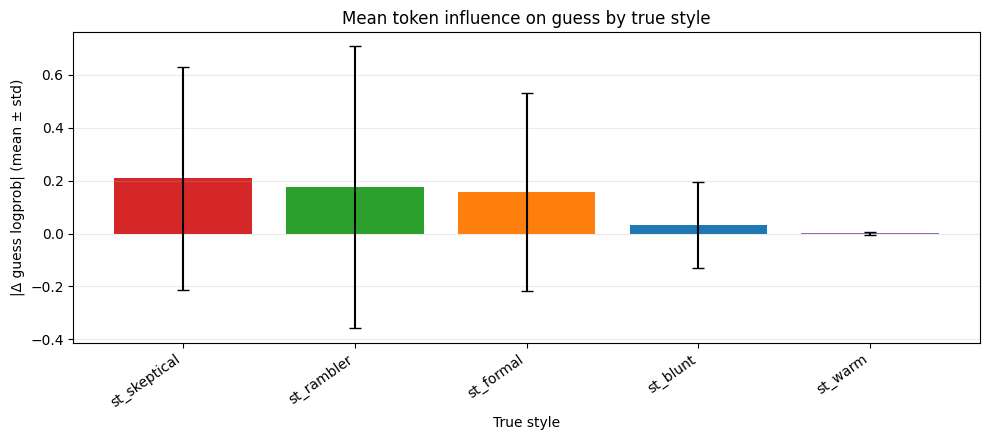

In [14]:
# === 6d. Mean |Δ guess logprob| by style ===
#
# Which styles have tokens with the strongest influence on the guess?

attr_guess["abs_delta"] = attr_guess["delta_guess_total_logprob"].abs()

style_influence = attr_guess.groupby("style_id")["abs_delta"].agg(["mean", "std", "max"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [STYLE_COLORS.get(s, "#888") for s in style_influence.index]
ax.bar(style_influence.index, style_influence["mean"], yerr=style_influence["std"], color=colors, capsize=4)
ax.set_ylabel("|Δ guess logprob| (mean ± std)")
ax.set_xlabel("True style")
ax.set_title("Mean token influence on guess by true style")
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

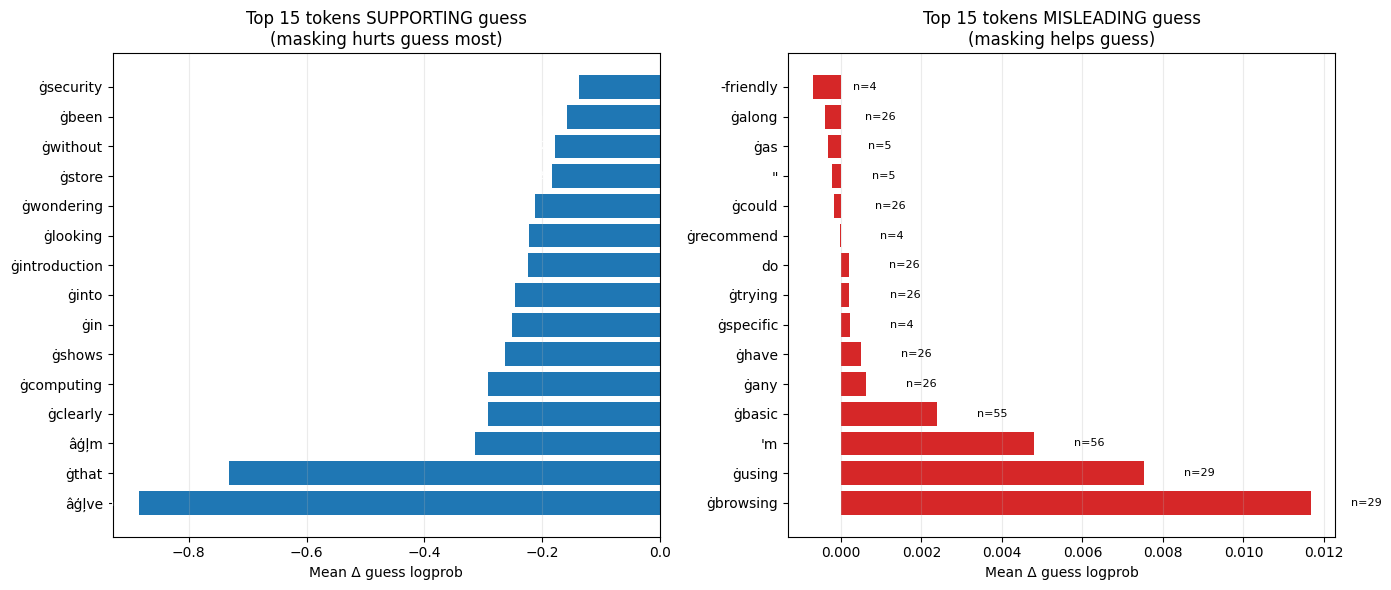

In [15]:
# === 6e. Top tokens aggregated across events ===
#
# For each unique token string, compute mean delta across all events.
# This reveals which WORDS (not just token positions) the model systematically relies on.

attr_guess["token_lower"] = attr_guess["token_clean"].str.lower().str.strip()

# Filter out empty/whitespace tokens
mask_nonempty = attr_guess["token_lower"].str.len() > 0

token_agg = (
    attr_guess[mask_nonempty]
    .groupby("token_lower")
    .agg(
        mean_delta=("delta_guess_total_logprob", "mean"),
        abs_mean_delta=("abs_delta", "mean"),
        count=("delta_guess_total_logprob", "size"),
    )
)

# Require at least 3 occurrences for stability
token_agg = token_agg[token_agg["count"] >= 3].sort_values("mean_delta")

n_show = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: tokens that most SUPPORT the guess (negative delta)
ax = axes[0]
top_sup = token_agg.head(n_show)
ax.barh(top_sup.index, top_sup["mean_delta"], color="#1f77b4")
ax.set_xlabel("Mean Δ guess logprob")
ax.set_title(f"Top {n_show} tokens SUPPORTING guess\n(masking hurts guess most)")
ax.grid(True, axis="x", alpha=0.25)
for i, (idx, row) in enumerate(top_sup.iterrows()):
    ax.text(row["mean_delta"] - 0.001, i, f"n={int(row['count'])}", va="center", ha="right", fontsize=8, color="white")

# Right: tokens that MISLEAD the guess (positive delta)
ax = axes[1]
top_mis = token_agg.tail(n_show).iloc[::-1]
ax.barh(top_mis.index, top_mis["mean_delta"], color="#d62728")
ax.set_xlabel("Mean Δ guess logprob")
ax.set_title(f"Top {n_show} tokens MISLEADING guess\n(masking helps guess)")
ax.grid(True, axis="x", alpha=0.25)
for i, (idx, row) in enumerate(top_mis.iterrows()):
    ax.text(row["mean_delta"] + 0.001, i, f"n={int(row['count'])}", va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.show()

Example: conversation=b9095e3f-dcf7-49c8-a12d-08082411bce9, turn=1
True style: st_blunt, Guess: st_warm, LR_mean: -7.500


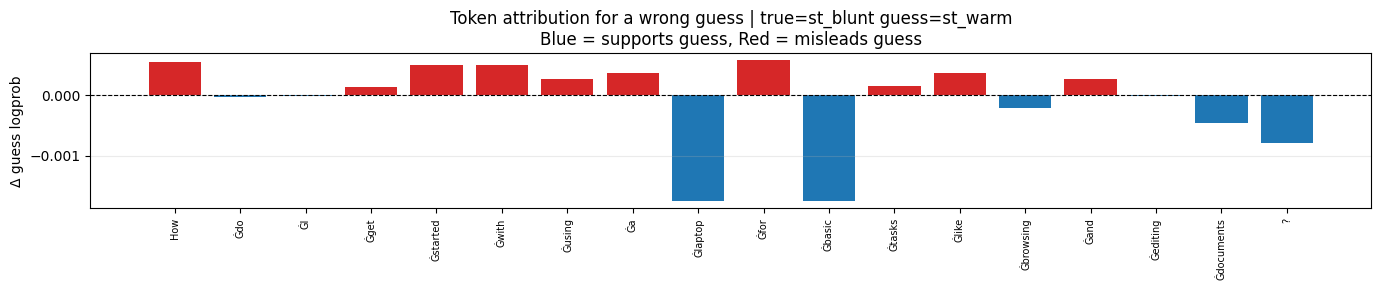

In [16]:
# === 6f. Attribution heatmap: example conversation ===
#
# Pick one conversation where the guess is WRONG and show
# which tokens in the user messages had the biggest influence.

# Pick a wrong guess with the most extreme LR
wrong_events = df[~df["correct"]].copy()
example_row = wrong_events.loc[wrong_events["lr_mean_true_minus_guess"].idxmin()]
example_cid = example_row["conversation_id"]
example_turn = example_row["turn_idx"]

print(f"Example: conversation={example_cid}, turn={example_turn}")
print(f"True style: {example_row['style_id']}, Guess: {example_row['guess']}, LR_mean: {example_row['lr_mean_true_minus_guess']:.3f}")

# Get attribution for this event
event_attr = attr_guess[
    (attr_guess["conversation_id"] == example_cid) &
    (attr_guess["turn_idx"] == example_turn)
].copy()

event_attr["token_display"] = event_attr["token_clean"].where(event_attr["token_clean"].str.len() > 0, "[sp]")

fig, ax = plt.subplots(figsize=(14, 3))
colors_bar = ["#d62728" if d > 0 else "#1f77b4" for d in event_attr["delta_guess_total_logprob"]]
ax.bar(range(len(event_attr)), event_attr["delta_guess_total_logprob"], color=colors_bar)
ax.set_xticks(range(len(event_attr)))
ax.set_xticklabels(event_attr["token_display"].values, rotation=90, fontsize=7)
ax.set_ylabel("Δ guess logprob")
ax.set_title(
    f"Token attribution for a wrong guess | true={example_row['style_id']} guess={example_row['guess']}\n"
    f"Blue = supports guess, Red = misleads guess"
)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Example: conversation=06d9f0d4-334e-413d-b803-e0da680f2658, turn=3
True style: st_skeptical, Guess: st_skeptical (CORRECT)


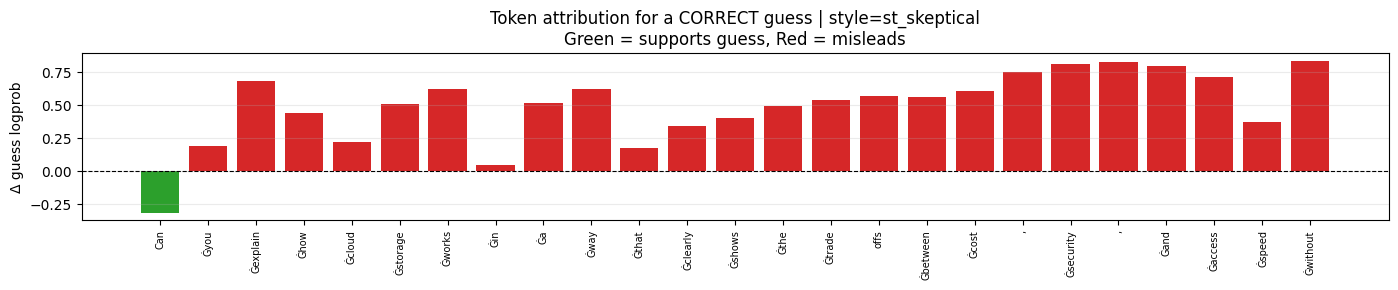

In [17]:
# === 6g. Attribution heatmap: example CORRECT guess ===

correct_events = df[df["correct"]].copy()
if len(correct_events) > 0:
    # Pick a correct guess with the largest attribution spread
    best_idx = None
    best_spread = 0
    for idx, row in correct_events.iterrows():
        parsed = json.loads(row["guess_token_attr_json"])
        deltas = [e["delta_guess_total_logprob"] for e in parsed]
        spread = max(deltas) - min(deltas) if deltas else 0
        if spread > best_spread:
            best_spread = spread
            best_idx = idx

    ex = correct_events.loc[best_idx]
    print(f"Example: conversation={ex['conversation_id']}, turn={ex['turn_idx']}")
    print(f"True style: {ex['style_id']}, Guess: {ex['guess']} (CORRECT)")

    ev_attr = attr_guess[
        (attr_guess["conversation_id"] == ex["conversation_id"]) &
        (attr_guess["turn_idx"] == ex["turn_idx"])
    ].copy()
    ev_attr["token_display"] = ev_attr["token_clean"].where(ev_attr["token_clean"].str.len() > 0, "[sp]")

    fig, ax = plt.subplots(figsize=(14, 3))
    colors_bar = ["#d62728" if d > 0 else "#2ca02c" for d in ev_attr["delta_guess_total_logprob"]]
    ax.bar(range(len(ev_attr)), ev_attr["delta_guess_total_logprob"], color=colors_bar)
    ax.set_xticks(range(len(ev_attr)))
    ax.set_xticklabels(ev_attr["token_display"].values, rotation=90, fontsize=7)
    ax.set_ylabel("Δ guess logprob")
    ax.set_title(
        f"Token attribution for a CORRECT guess | style={ex['style_id']}\n"
        f"Green = supports guess, Red = misleads"
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No correct guesses found.")

## 7. The st_warm Bias

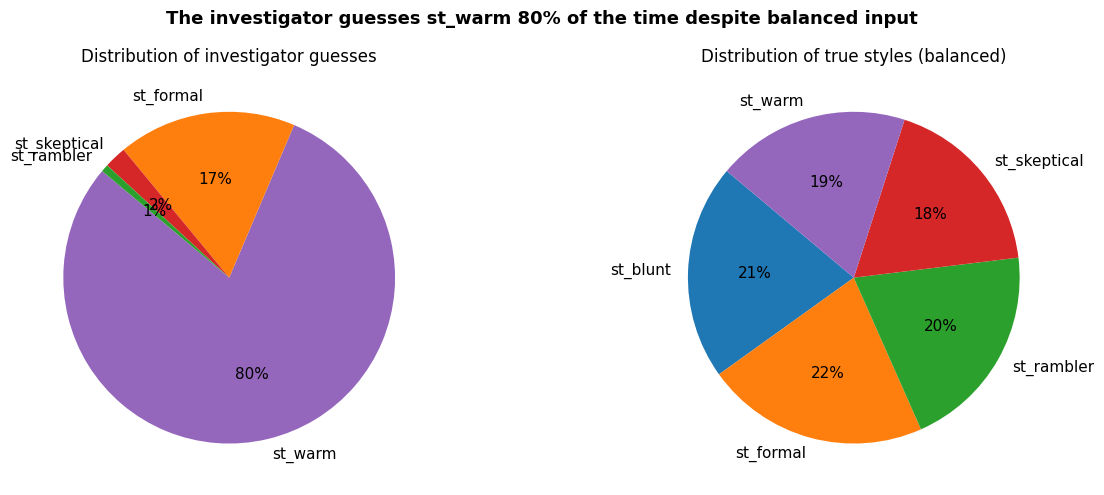

In [18]:
# === 7a. Guess distribution pie chart ===

guess_counts = df["guess"].value_counts()
colors_pie = [STYLE_COLORS.get(s, "#888") for s in guess_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: guess distribution
ax = axes[0]
ax.pie(guess_counts.values, labels=guess_counts.index, colors=colors_pie,
       autopct="%1.0f%%", startangle=140, textprops={"fontsize": 11})
ax.set_title("Distribution of investigator guesses")

# Right: true style distribution
ax = axes[1]
true_counts = df["style_id"].value_counts().sort_index()
colors_true = [STYLE_COLORS.get(s, "#888") for s in true_counts.index]
ax.pie(true_counts.values, labels=true_counts.index, colors=colors_true,
       autopct="%1.0f%%", startangle=140, textprops={"fontsize": 11})
ax.set_title("Distribution of true styles (balanced)")

plt.suptitle("The investigator guesses st_warm 80% of the time despite balanced input", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

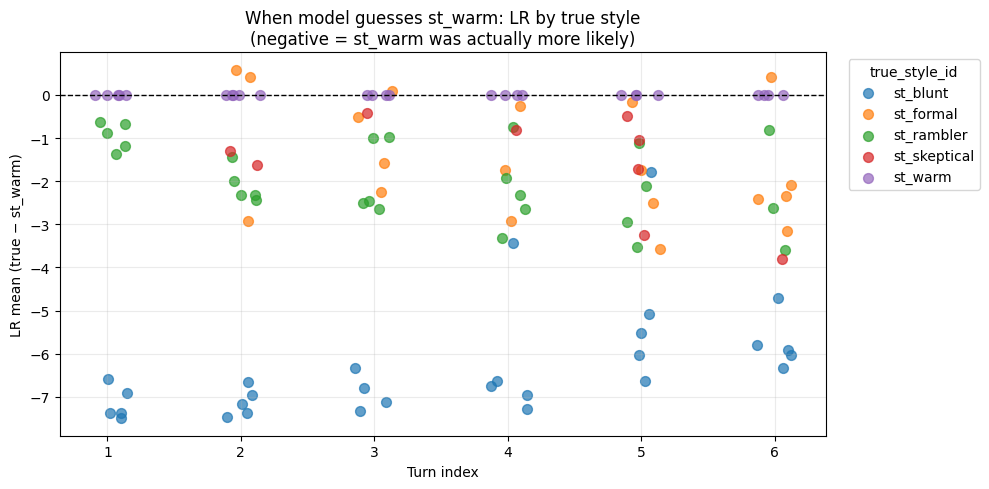

In [19]:
# === 7b. LR by true style (when guess is st_warm) ===
#
# For all events where the model guessed st_warm,
# what does LR look like per true style?
# Negative LR means the model's guess (st_warm) was actually more likely than truth.

warm_guesses = df[df["guess"] == "st_warm"].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for style in sorted(warm_guesses["style_id"].unique()):
    sub = warm_guesses[warm_guesses["style_id"] == style]
    ax.scatter(
        sub["turn_idx"] + np.random.uniform(-0.15, 0.15, len(sub)),  # jitter
        sub["lr_mean_true_minus_guess"],
        label=style, color=STYLE_COLORS.get(style), alpha=0.7, s=50
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Turn index")
ax.set_ylabel("LR mean (true − st_warm)")
ax.set_title("When model guesses st_warm: LR by true style\n(negative = st_warm was actually more likely)")
ax.set_xticks(sorted(warm_guesses["turn_idx"].unique()))
ax.legend(title="true_style_id", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

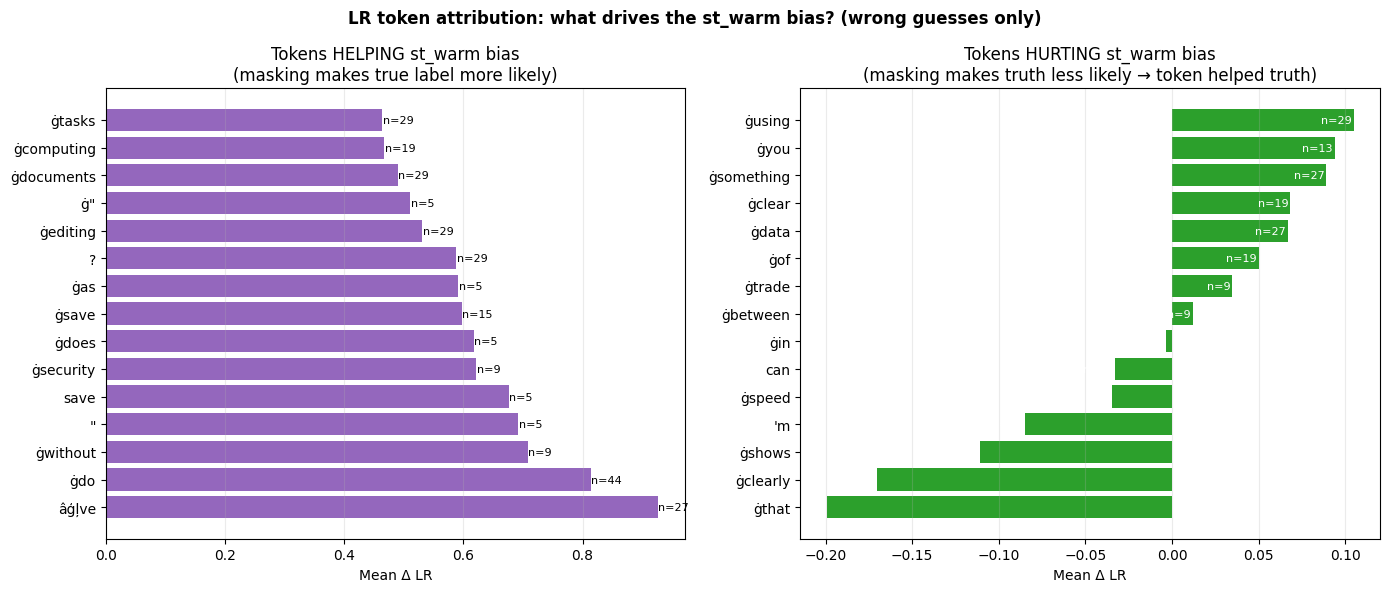

In [20]:
# === 7c. What tokens push AWAY from st_warm? (LR attribution) ===
#
# For events where guess=st_warm but true!=st_warm,
# which tokens have the largest Δ_LR (i.e., masking them makes the true label
# relatively more likely → the token was helping st_warm over truth)

wrong_warm = df[(df["guess"] == "st_warm") & (~df["correct"])]
attr_lr_ww = attr_lr[
    attr_lr["conversation_id"].isin(wrong_warm["conversation_id"]) &
    attr_lr["turn_idx"].isin(wrong_warm["turn_idx"])
].copy()

# Merge to get correct event matching
attr_lr_ww = attr_lr_ww.merge(
    wrong_warm[["conversation_id", "turn_idx"]].drop_duplicates(),
    on=["conversation_id", "turn_idx"],
    how="inner"
)

attr_lr_ww["token_clean"] = attr_lr_ww["token"].fillna("").str.replace("▁", " ", regex=False).str.strip()
attr_lr_ww["token_lower"] = attr_lr_ww["token_clean"].str.lower().str.strip()

mask_nonempty = attr_lr_ww["token_lower"].str.len() > 0

lr_tok_agg = (
    attr_lr_ww[mask_nonempty]
    .groupby("token_lower")
    .agg(
        mean_delta_lr=("delta_lr_mean", "mean"),
        count=("delta_lr_mean", "size"),
    )
)
lr_tok_agg = lr_tok_agg[lr_tok_agg["count"] >= 3].sort_values("mean_delta_lr")

n_show = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: tokens that HELPED st_warm over truth (positive Δ_LR = masking made truth more likely)
ax = axes[0]
top_help_warm = lr_tok_agg.tail(n_show).iloc[::-1]
ax.barh(top_help_warm.index, top_help_warm["mean_delta_lr"], color="#9467bd")
ax.set_xlabel("Mean Δ LR")
ax.set_title(f"Tokens HELPING st_warm bias\n(masking makes true label more likely)")
ax.grid(True, axis="x", alpha=0.25)
for i, (idx, row) in enumerate(top_help_warm.iterrows()):
    ax.text(row["mean_delta_lr"] + 0.001, i, f"n={int(row['count'])}", va="center", fontsize=8)

# Right: tokens that HURT st_warm (negative Δ_LR = masking made truth less likely → token helped truth)
ax = axes[1]
top_hurt_warm = lr_tok_agg.head(n_show)
ax.barh(top_hurt_warm.index, top_hurt_warm["mean_delta_lr"], color="#2ca02c")
ax.set_xlabel("Mean Δ LR")
ax.set_title(f"Tokens HURTING st_warm bias\n(masking makes truth less likely → token helped truth)")
ax.grid(True, axis="x", alpha=0.25)
for i, (idx, row) in enumerate(top_hurt_warm.iterrows()):
    ax.text(row["mean_delta_lr"] - 0.001, i, f"n={int(row['count'])}", va="center", ha="right", fontsize=8, color="white")

plt.suptitle("LR token attribution: what drives the st_warm bias? (wrong guesses only)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Summary

In [21]:
# === Summary statistics ===

print("=" * 60)
print("INVESTIGATOR ATTRIBUTION — SUMMARY")
print("=" * 60)
print(f"Total guess events scored: {len(df)}")
print(f"Unique conversations: {df['conversation_id'].nunique()}")
print(f"Styles: {sorted(df['style_id'].unique())}")
print(f"Turns: {sorted(df['turn_idx'].unique())}")
print()
print(f"Overall accuracy: {df['correct'].mean()*100:.1f}%")
print(f"Guess distribution: {dict(df['guess'].value_counts())}")
print(f"st_warm bias: {(df['guess'] == 'st_warm').mean()*100:.0f}% of all guesses")
print()
print("Accuracy by style:")
for style in sorted(df['style_id'].unique()):
    sub = df[df['style_id'] == style]
    print(f"  {style}: {sub['correct'].mean()*100:.0f}% ({sub['correct'].sum()}/{len(sub)})")
print()
print(f"Mean confidence (correct): {df.loc[df['correct'], 'confidence'].mean():.1f}")
print(f"Mean confidence (wrong):   {df.loc[~df['correct'], 'confidence'].mean():.1f}")
print(f"  → Model is equally confident when right and wrong")
print()
print(f"Mean LR (correct guesses): {df.loc[df['correct'], 'lr_mean_true_minus_guess'].mean():.3f}")
print(f"Mean LR (wrong guesses):   {df.loc[~df['correct'], 'lr_mean_true_minus_guess'].mean():.3f}")
print(f"  → When wrong, the true label was much less likely than st_warm")
print()
meaningful = (attr_guess['delta_guess_total_logprob'].abs() >= 0.01).mean()
print(f"Token attributions with |Δ| >= 0.01: {meaningful*100:.0f}%")
print(f"Total token attributions: {len(attr_guess)}")

INVESTIGATOR ATTRIBUTION — SUMMARY
Total guess events scored: 138
Unique conversations: 25
Styles: ['st_blunt', 'st_formal', 'st_rambler', 'st_skeptical', 'st_warm']
Turns: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Overall accuracy: 28.3%
Guess distribution: {'st_warm': np.int64(110), 'st_formal': np.int64(24), 'st_skeptical': np.int64(3), 'st_rambler': np.int64(1)}
st_warm bias: 80% of all guesses

Accuracy by style:
  st_blunt: 0% (0/29)
  st_formal: 33% (10/30)
  st_rambler: 4% (1/28)
  st_skeptical: 8% (2/25)
  st_warm: 100% (26/26)

Mean confidence (correct): 92.2
Mean confidence (wrong):   92.0
  → Model is equally confident when right and wrong

Mean LR (correct guesses): 0.000
Mean LR (wrong guesses):   -3.170
  → When wrong, the true label was much less likely than st_warm

Token attributions with |Δ| >= 0.01: 33%
Total token attributions: 3415
